In [83]:
## Decision tree algorithm

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
## loding dataset

In [86]:
df=pd.read_csv(r"C:\Users\DIWAKAR YADAV\Downloads\Social_media_impact_on_life_Clean_Dataset.csv")

In [87]:
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [88]:
df.shape

(1705, 9)

In [89]:
df.drop(columns=['Mental_Health_Score'],inplace=True)

In [90]:
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,Negative


In [91]:
df.shape

(1705, 8)

In [92]:
## separating input and output feature

In [93]:
X=df.iloc[:,0:7]  ## input faeture
y=df.iloc[:,-1]    ## output feature

In [94]:
X.shape

(1705, 7)

In [95]:
y

0        Neutral
1       Positive
2        Neutral
3       Negative
4       Negative
          ...   
1700    Positive
1701    Negative
1702    Negative
1703    Positive
1704    Negative
Name: Overall_Impact, Length: 1705, dtype: object

target column is categorical

In [96]:
y.unique()

array(['Neutral', 'Positive', 'Negative'], dtype=object)

In [97]:
## appling label encoder on target/output feature 
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [98]:
y

array([1, 2, 1, ..., 0, 2, 0], shape=(1705,))

In [99]:
## separating numerical column and categorical columns

In [100]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [101]:
## numerical columns
num_cols

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night'], dtype='object')

In [102]:
## categorical columns
cat_cols

Index(['Gender', 'Academic_Level', 'Most_Used_Platform',
       'Affects_Academic_Performance'],
      dtype='object')

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [104]:
## Numerical pipeline
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

## Categorical pipeline
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [105]:
## Combining both pipeline (numerical+categorical)
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [106]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
X_train.shape

(1364, 7)

In [108]:
X_test.shape

(341, 7)

In [109]:
y_train.shape

(1364,)

In [110]:
y_test.shape

(341,)

In [111]:
## Training the model

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [140]:
def model_evaluate(n_stimators,depth):
    depths=[]
    accuracies=[]

    ## training model to max depth
    for depth in range(1,depth+1):
    
        ## Random Forest model
        rf_model = RandomForestClassifier(
            n_estimators=n_stimators,
            max_depth=depth,
            random_state=42
        )
    
        ## full pipeline
        model = Pipeline([
            ('preprocessing', preprocessor),
            ('classifier', rf_model)
        ])
    
        ## train model
        model.fit(X_train, y_train)
    
        ## Predict
        y_pred = model.predict(X_test)
    
        ## Accuracy
        accuracy = accuracy_score(y_test, y_pred)
    
        depths.append(depth)
        accuracies.append(accuracy)
    
        print(f"Depth: {depth}, Accuracy: {accuracy}")

    # Visualization
    plt.figure(figsize=(8,5))
    
    plt.plot(depths, accuracies, marker='o')
    
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    
    plt.title("Random Forest Accuracy vs Max Depth")
    
    plt.grid(True)
    
    plt.show()
    
    # Best depth
    best_index = accuracies.index(max(accuracies))

    print("Best Depth:", depths[best_index])
    print("Best Accuracy:", accuracies[best_index])

Depth: 1, Accuracy: 0.8269794721407625
Depth: 2, Accuracy: 0.8387096774193549
Depth: 3, Accuracy: 0.841642228739003
Depth: 4, Accuracy: 0.873900293255132
Depth: 5, Accuracy: 0.9002932551319648
Depth: 6, Accuracy: 0.9237536656891495
Depth: 7, Accuracy: 0.9413489736070382
Depth: 8, Accuracy: 0.9413489736070382
Depth: 9, Accuracy: 0.9442815249266863
Depth: 10, Accuracy: 0.9560117302052786
Depth: 11, Accuracy: 0.9530791788856305
Depth: 12, Accuracy: 0.9530791788856305
Depth: 13, Accuracy: 0.9560117302052786
Depth: 14, Accuracy: 0.9589442815249267
Depth: 15, Accuracy: 0.9560117302052786
Depth: 16, Accuracy: 0.9560117302052786
Depth: 17, Accuracy: 0.9560117302052786
Depth: 18, Accuracy: 0.9560117302052786
Depth: 19, Accuracy: 0.9560117302052786
Depth: 20, Accuracy: 0.9560117302052786
Depth: 21, Accuracy: 0.9560117302052786
Depth: 22, Accuracy: 0.9560117302052786
Depth: 23, Accuracy: 0.9560117302052786
Depth: 24, Accuracy: 0.9560117302052786
Depth: 25, Accuracy: 0.9560117302052786


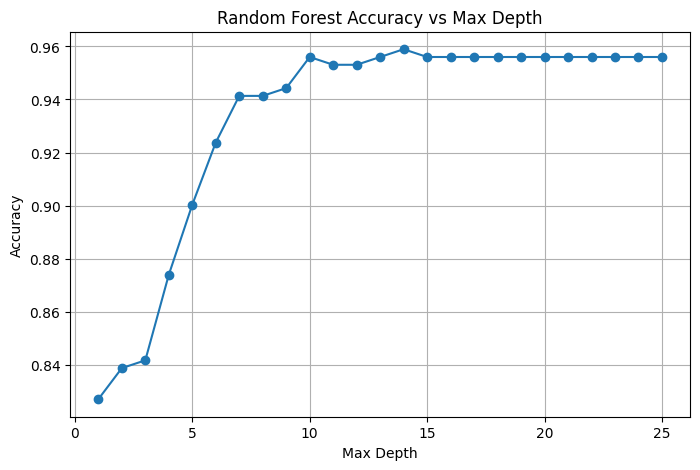

Best Depth: 14
Best Accuracy: 0.9589442815249267


In [143]:
E1=model_evaluate(100,25)

Depth: 1, Accuracy: 0.8211143695014663
Depth: 2, Accuracy: 0.8299120234604106
Depth: 3, Accuracy: 0.844574780058651
Depth: 4, Accuracy: 0.8797653958944281
Depth: 5, Accuracy: 0.8973607038123167
Depth: 6, Accuracy: 0.9149560117302052
Depth: 7, Accuracy: 0.9266862170087976
Depth: 8, Accuracy: 0.9442815249266863
Depth: 9, Accuracy: 0.9413489736070382
Depth: 10, Accuracy: 0.9530791788856305
Depth: 11, Accuracy: 0.9472140762463344
Depth: 12, Accuracy: 0.9501466275659824
Depth: 13, Accuracy: 0.9530791788856305
Depth: 14, Accuracy: 0.9560117302052786
Depth: 15, Accuracy: 0.9530791788856305
Depth: 16, Accuracy: 0.9589442815249267
Depth: 17, Accuracy: 0.9560117302052786
Depth: 18, Accuracy: 0.9560117302052786
Depth: 19, Accuracy: 0.9560117302052786
Depth: 20, Accuracy: 0.9560117302052786
Depth: 21, Accuracy: 0.9560117302052786
Depth: 22, Accuracy: 0.9560117302052786
Depth: 23, Accuracy: 0.9560117302052786
Depth: 24, Accuracy: 0.9560117302052786
Depth: 25, Accuracy: 0.9560117302052786


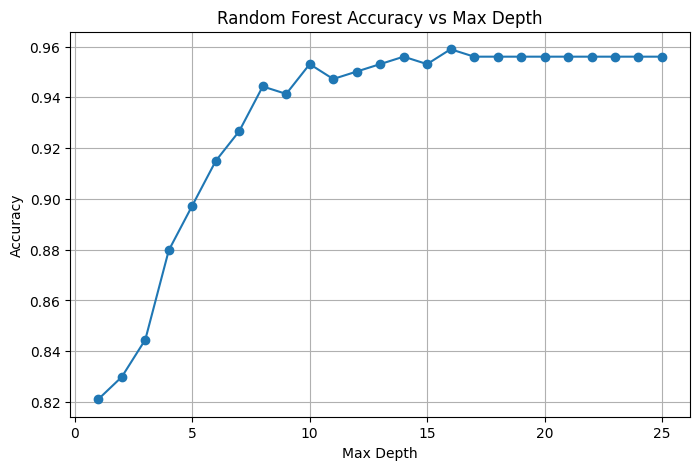

Best Depth: 16
Best Accuracy: 0.9589442815249267


In [151]:
E2=model_evaluate(80,25)

Depth: 1, Accuracy: 0.8240469208211144
Depth: 2, Accuracy: 0.8328445747800587
Depth: 3, Accuracy: 0.8504398826979472
Depth: 4, Accuracy: 0.8885630498533724
Depth: 5, Accuracy: 0.9002932551319648
Depth: 6, Accuracy: 0.9208211143695014
Depth: 7, Accuracy: 0.9354838709677419
Depth: 8, Accuracy: 0.9413489736070382
Depth: 9, Accuracy: 0.9442815249266863
Depth: 10, Accuracy: 0.9530791788856305
Depth: 11, Accuracy: 0.9530791788856305
Depth: 12, Accuracy: 0.9501466275659824
Depth: 13, Accuracy: 0.9560117302052786
Depth: 14, Accuracy: 0.9618768328445748
Depth: 15, Accuracy: 0.9560117302052786
Depth: 16, Accuracy: 0.9589442815249267
Depth: 17, Accuracy: 0.9560117302052786
Depth: 18, Accuracy: 0.9589442815249267
Depth: 19, Accuracy: 0.9589442815249267
Depth: 20, Accuracy: 0.9589442815249267
Depth: 21, Accuracy: 0.9589442815249267
Depth: 22, Accuracy: 0.9589442815249267
Depth: 23, Accuracy: 0.9589442815249267
Depth: 24, Accuracy: 0.9589442815249267
Depth: 25, Accuracy: 0.9589442815249267


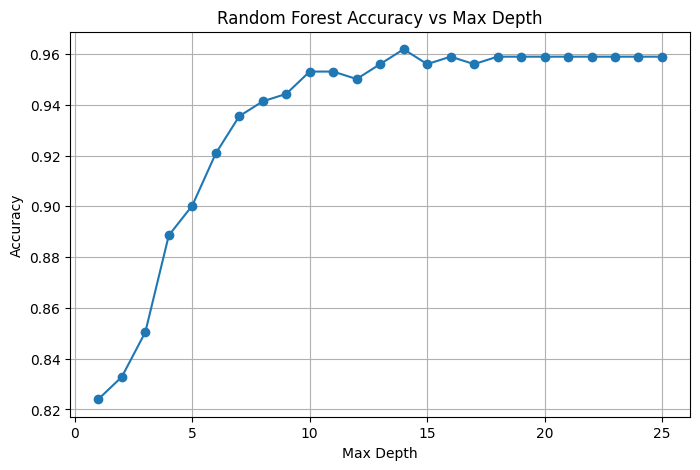

Best Depth: 14
Best Accuracy: 0.9618768328445748


In [152]:
E3=model_evaluate(50,25)

Depth: 1, Accuracy: 0.7947214076246334
Depth: 2, Accuracy: 0.8123167155425219
Depth: 3, Accuracy: 0.8533724340175953
Depth: 4, Accuracy: 0.8826979472140762
Depth: 5, Accuracy: 0.8944281524926686
Depth: 6, Accuracy: 0.9149560117302052
Depth: 7, Accuracy: 0.9296187683284457
Depth: 8, Accuracy: 0.9384164222873901
Depth: 9, Accuracy: 0.9472140762463344
Depth: 10, Accuracy: 0.9530791788856305
Depth: 11, Accuracy: 0.9501466275659824
Depth: 12, Accuracy: 0.9501466275659824
Depth: 13, Accuracy: 0.9589442815249267
Depth: 14, Accuracy: 0.9589442815249267
Depth: 15, Accuracy: 0.9501466275659824
Depth: 16, Accuracy: 0.9560117302052786
Depth: 17, Accuracy: 0.9501466275659824
Depth: 18, Accuracy: 0.9530791788856305
Depth: 19, Accuracy: 0.9530791788856305
Depth: 20, Accuracy: 0.9501466275659824
Depth: 21, Accuracy: 0.9501466275659824
Depth: 22, Accuracy: 0.9501466275659824
Depth: 23, Accuracy: 0.9501466275659824
Depth: 24, Accuracy: 0.9501466275659824
Depth: 25, Accuracy: 0.9501466275659824


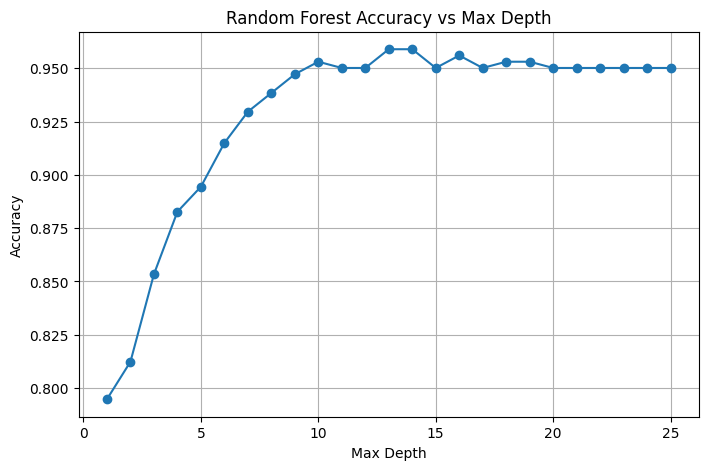

Best Depth: 13
Best Accuracy: 0.9589442815249267


In [153]:
E4=model_evaluate(30,25)

Depth: 1, Accuracy: 0.8299120234604106
Depth: 2, Accuracy: 0.8064516129032258
Depth: 3, Accuracy: 0.8651026392961877
Depth: 4, Accuracy: 0.8826979472140762
Depth: 5, Accuracy: 0.8914956011730205
Depth: 6, Accuracy: 0.9178885630498533
Depth: 7, Accuracy: 0.9325513196480938
Depth: 8, Accuracy: 0.9442815249266863
Depth: 9, Accuracy: 0.9325513196480938
Depth: 10, Accuracy: 0.9530791788856305
Depth: 11, Accuracy: 0.9501466275659824
Depth: 12, Accuracy: 0.9501466275659824
Depth: 13, Accuracy: 0.9530791788856305
Depth: 14, Accuracy: 0.9442815249266863
Depth: 15, Accuracy: 0.9442815249266863
Depth: 16, Accuracy: 0.9530791788856305
Depth: 17, Accuracy: 0.9560117302052786
Depth: 18, Accuracy: 0.9560117302052786
Depth: 19, Accuracy: 0.9560117302052786
Depth: 20, Accuracy: 0.9560117302052786
Depth: 21, Accuracy: 0.9560117302052786
Depth: 22, Accuracy: 0.9560117302052786
Depth: 23, Accuracy: 0.9560117302052786
Depth: 24, Accuracy: 0.9560117302052786
Depth: 25, Accuracy: 0.9560117302052786


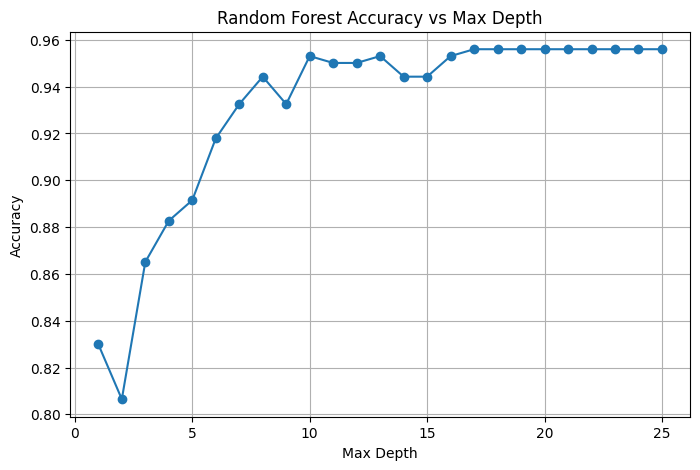

Best Depth: 17
Best Accuracy: 0.9560117302052786


In [154]:
E5=model_evaluate(20,25)

                                            
---------------------------------------------------------------------------------------------------
| Model             | n_estimators                  | Best Depth             | Best Accuracy      |
|-------------------|-------------------------------|------------------------|--------------------|
| E1                | 100                           | 14                     | 0.9589442815249267 |           
| E2                | 80                            | 16                     | 0.9589442815249267 |             
| E3                | 50                            | 14                     | 0.9618768328445748 |
| E4                | 30                            | 13                     | 0.9589442815249267 |
| E5                | 20                            | 17                     | 0.9589442815249267 |

#### Conclusion :
- n_estimators: 50    (numbers of base models)
- At depth: 14 
- best accuracy: 0.9618768328445748

In [173]:
## Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=14,
    random_state=42
)

## Full pipeline
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', rf_model)
])

# Train model
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
## Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("model accuracy:",accuracy)

model accuracy: 0.9618768328445748


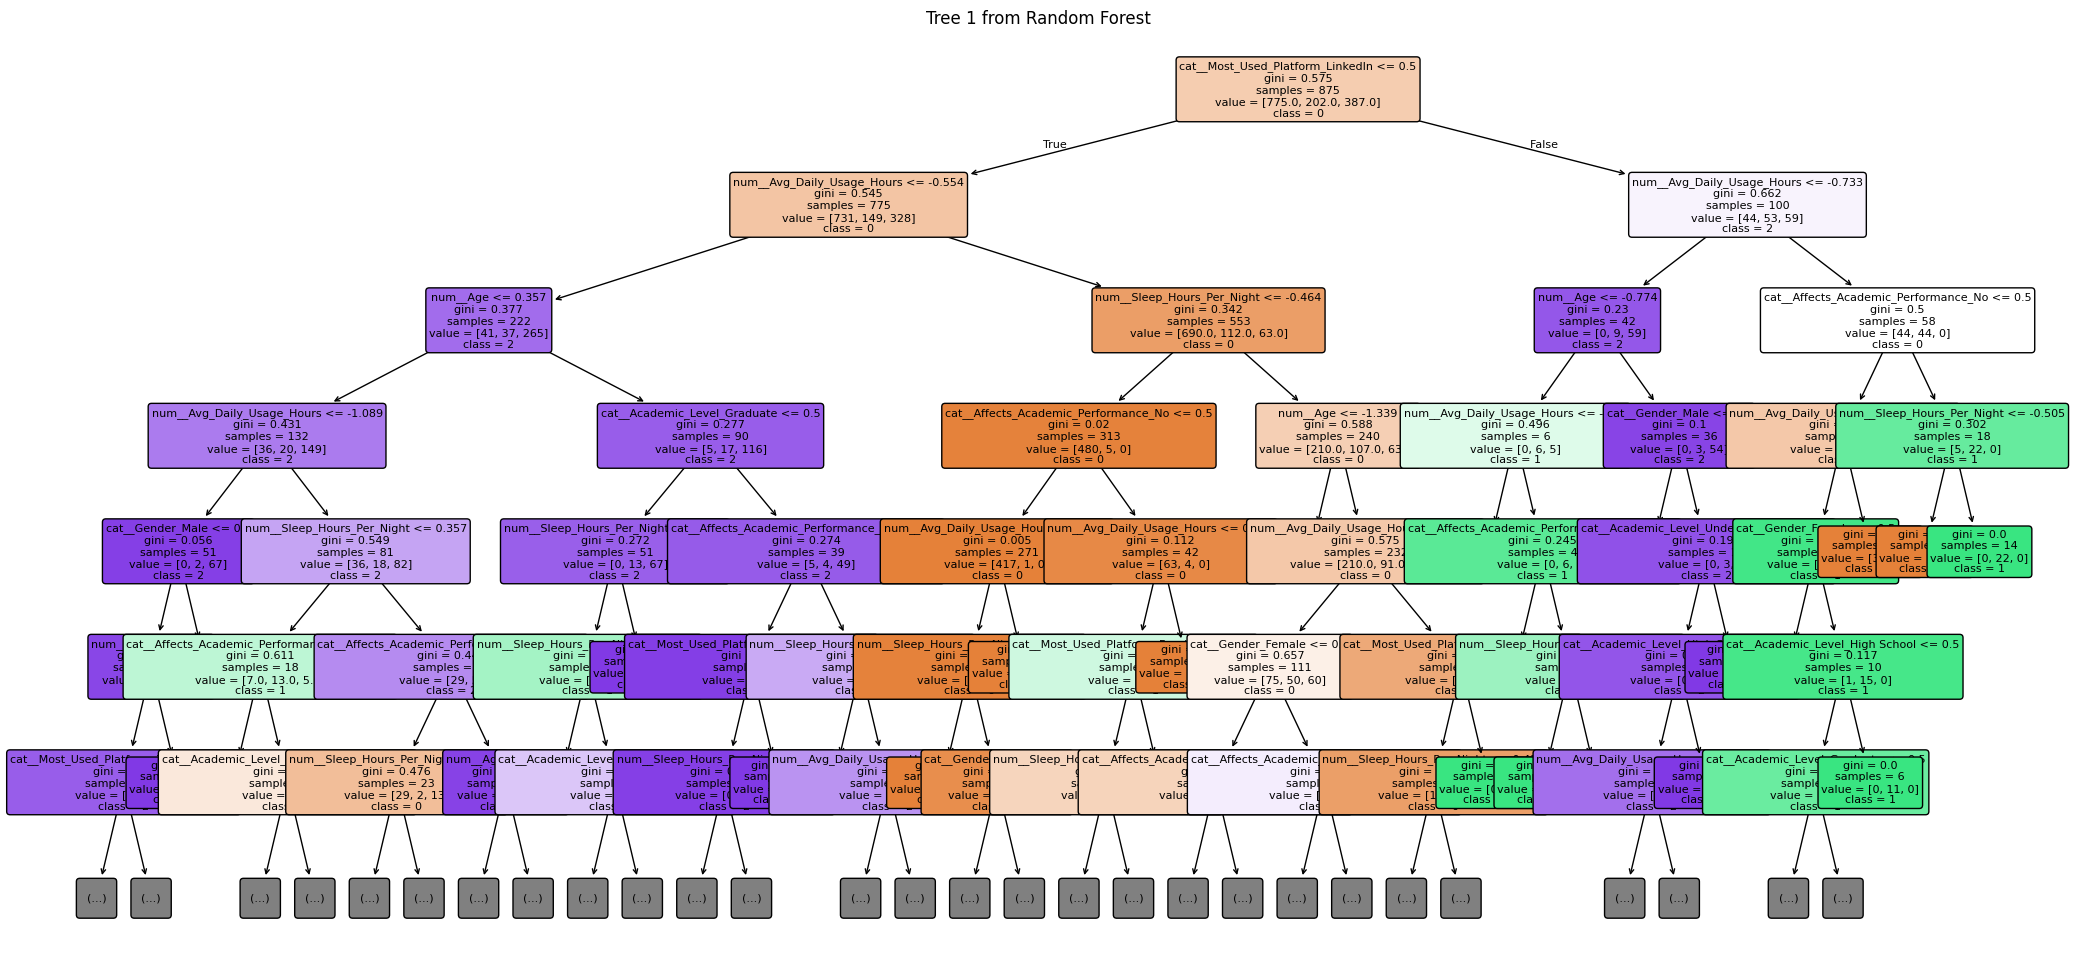

In [174]:
# ploting tree structure of base model
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract trained Random Forest
rf = model.named_steps['classifier']

# Get transformed feature names
feature_names = model.named_steps[
    'preprocessing'
].get_feature_names_out()

# Number of trees to visualize
n_trees = 1

for i in range(n_trees):

    # Select tree
    tree = rf.estimators_[i]

    # Plot
    plt.figure(figsize=(25, 12))

    plot_tree(
        tree,
        filled=True,
        rounded=True,
        fontsize=8,
        feature_names=feature_names,
        class_names=[str(c) for c in rf.classes_],
        max_depth=6
    )

    plt.title(f"Tree {i+1} from Random Forest")

    plt.show()